Train: 2015-01-01 -> 2023-12-01 n= 108
Test : 2024-01-01 -> 2025-12-01 n= 24

Best ENet params: {'model__alpha': np.float64(0.016037187437513277), 'model__l1_ratio': 0.7}

=== Model comparison (sorted by RMSE) ===
                                    model       MAE      RMSE        R2  \
0                           Naive (lag-1)  0.004167  0.020412  0.777778   
1  Linear Regression (lags1..12 + season)  0.017298  0.026200  0.633905   
2                       ETS-Seasonal (12)  0.047053  0.052512 -0.470659   
3                   ElasticNet (CV tuned)  0.050921  0.054361 -0.576046   
4                       ETS-Holt (damped)  0.054833  0.062007 -1.050586   
5                 Seasonal Naive (lag-12)  0.062500  0.079057 -2.333333   
6                         ETS-SES (level)  0.075000  0.086603 -3.000000   
7                          ARIMA(1, 1, 1)  0.075000  0.086603 -3.000000   

    MASE_m1  MASE_m12  
0  0.405303  0.054795  
1  1.682629  0.227481  
2  4.576977  0.618780  
3  4.953215  0

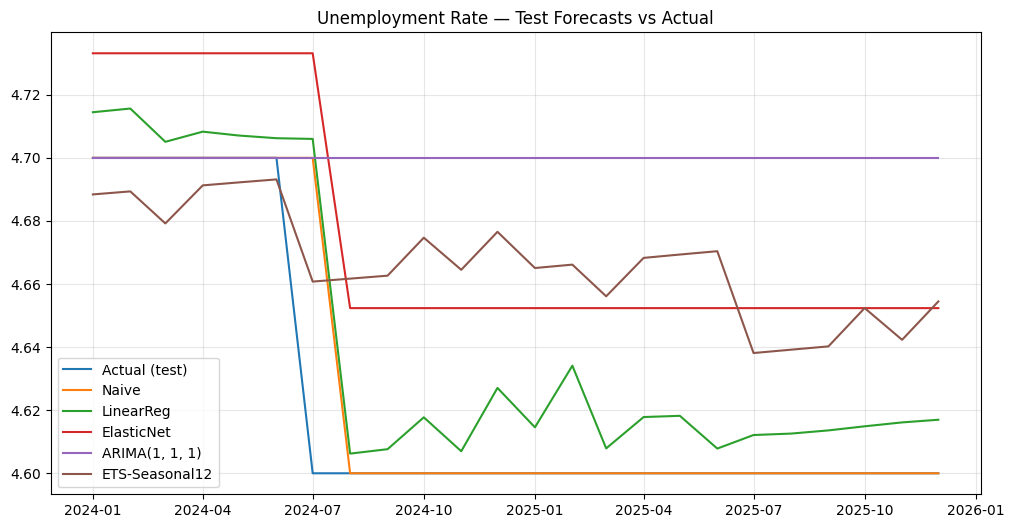


=== Next 12-month forecast (best by RMSE) ===
2026-01-01    4.6
2026-02-01    4.6
2026-03-01    4.6
2026-04-01    4.6
2026-05-01    4.6
2026-06-01    4.6
2026-07-01    4.6
2026-08-01    4.6
2026-09-01    4.6
2026-10-01    4.6
2026-11-01    4.6
2026-12-01    4.6
Freq: MS, dtype: float64


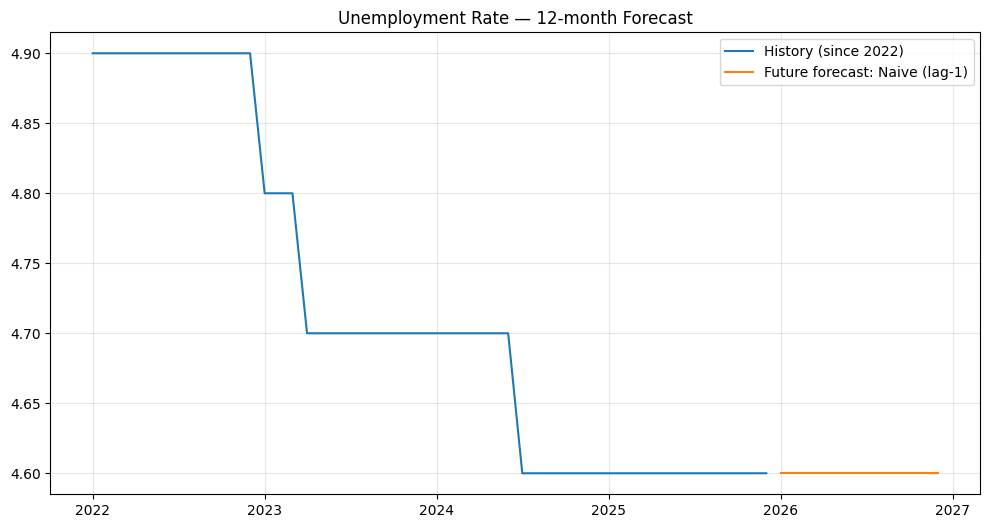

In [2]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl

from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing


# ----------------------------
# CONFIG
# ----------------------------

FILE_PATH =   "../data/unemployment_rate.xlsx"  # .../your_project/data/unemployment_rate.xlsx"
SHEET_NAME = "unemployed_rate"
DATE_COL = "Date"
Y_COL = "UnemploymentRate"

TRAIN_START = "2015-01-01"
TRAIN_END   = "2023-12-01"
TEST_START  = "2024-01-01"
TEST_END    = "2025-12-01"

FREQ = "MS"          # monthly start
MAX_LAG = 12         # use consecutive lags for valid recursive multi-step
ARIMA_ORDER = (1, 1, 1)
H_FUTURE = 12        # future forecast horizon


# ----------------------------
# HELPERS
# ----------------------------
def mase(y_true, y_pred, y_train, m=1):
    """
    Mean Absolute Scaled Error (MASE).
    Scale is MAE of naive m-lag forecast inside TRAIN.
    - m=1  : non-seasonal naive scale
    - m=12 : seasonal naive scale for monthly data
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_train = np.asarray(y_train, dtype=float)

    mae_val = np.mean(np.abs(y_true - y_pred))
    scale = np.mean(np.abs(y_train[m:] - y_train[:-m]))
    return np.nan if scale == 0 else mae_val / scale


def eval_metrics(y_true, y_pred, y_train):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float).reindex(y_true.index)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mase1 = mase(y_true, y_pred, y_train, m=1)
    mase12 = mase(y_true, y_pred, y_train, m=12) if len(y_train) > 12 else np.nan
    return mae, rmse, r2, mase1, mase12


def make_supervised(df, y_col, max_lag=12):
    """
    Create supervised dataset with consecutive lags lag_1..lag_max_lag
    + seasonal month sin/cos.
    """
    out = df.copy()
    for lag in range(1, max_lag + 1):
        out[f"lag_{lag}"] = out[y_col].shift(lag)

    out["month"] = out.index.month
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12.0)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12.0)

    out = out.dropna()
    feat_cols = [f"lag_{lag}" for lag in range(1, max_lag + 1)] + ["month_sin", "month_cos"]
    return out, feat_cols


def recursive_forecast_ml(model, last_row, feat_cols, steps=12, start_date=None):
    """
    Valid recursive forecast for ML model when feat_cols include lag_1..lag_12 and month_sin/cos.

    last_row: last available row from supervised df (contains lag_1..lag_12)
    steps: number of months ahead
    start_date: first forecast date (MS). If None, will infer.
    """
    # Extract last lags lag_1..lag_12
    last_lags = [float(last_row[f"lag_{i}"]) for i in range(1, 13)]  # [lag_1..lag_12]

    if start_date is None:
        start_date = last_row.name + pd.offsets.MonthBegin(1)

    idx = pd.date_range(start=start_date, periods=steps, freq="MS")
    preds = []

    for d in idx:
        month = d.month
        x = np.array(last_lags + [np.sin(2*np.pi*month/12.0), np.cos(2*np.pi*month/12.0)], dtype=float).reshape(1, -1)
        yhat = float(model.predict(x)[0])
        preds.append(yhat)

        # update lags: new forecast becomes lag_1
        last_lags = [yhat] + last_lags[:11]

    return pd.Series(preds, index=idx)


# ----------------------------
# 1) LOAD + PREPARE SERIES
# ----------------------------
df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], format="%m/%d/%y", errors="coerce")
df = df.dropna(subset=[DATE_COL, Y_COL]).sort_values(DATE_COL).set_index(DATE_COL)
df = df.asfreq(FREQ)

# IMPORTANT: do NOT use interpolation that looks into the future unless you are 100% sure no missing months exist.
# Safer fill for time series is forward fill.
df[Y_COL] = df[Y_COL].astype(float).ffill()
df = df.dropna(subset=[Y_COL])

y = df[Y_COL]

y_train_ts = y.loc[TRAIN_START:TRAIN_END]
y_test_ts  = y.loc[TEST_START:TEST_END]

print("Train:", y_train_ts.index.min().date(), "->", y_train_ts.index.max().date(), "n=", len(y_train_ts))
print("Test :", y_test_ts.index.min().date(),  "->", y_test_ts.index.max().date(),  "n=", len(y_test_ts))



# ----------------------------
# 2) BASELINES
# ----------------------------
# Naive (random walk / persistence): yhat_t = y_{t-1}
pred_naive = y.shift(1).loc[y_test_ts.index]

# Seasonal naive (m=12): yhat_t = y_{t-12}
pred_snaive = y.shift(12).loc[y_test_ts.index]

# Evaluate baselines
rows = []
mae, rmse, r2, mase1, mase12 = eval_metrics(y_test_ts, pred_naive, y_train_ts)
rows.append(["Naive (lag-1)", mae, rmse, r2, mase1, mase12])

mae, rmse, r2, mase1, mase12 = eval_metrics(y_test_ts, pred_snaive, y_train_ts)
rows.append(["Seasonal Naive (lag-12)", mae, rmse, r2, mase1, mase12])


# ----------------------------
# 3) SUPERVISED DATA (LAGS + SEASONAL FEATURES)
# ----------------------------
df_sup, feat_cols = make_supervised(df[[Y_COL]], Y_COL, max_lag=MAX_LAG)

train_df = df_sup.loc[TRAIN_START:TRAIN_END].copy()
test_df  = df_sup.loc[TEST_START:TEST_END].copy()

X_train = train_df[feat_cols]
y_train = train_df[Y_COL]
X_test  = test_df[feat_cols]
y_test  = test_df[Y_COL]


# ----------------------------
# 4) LINEAR REGRESSION (lags + month sin/cos)
# ----------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = pd.Series(lr.predict(X_test), index=y_test.index)

mae, rmse, r2, mase1, mase12 = eval_metrics(y_test, pred_lr, y_train)
rows.append(["Linear Regression (lags1..12 + season)", mae, rmse, r2, mase1, mase12])


# ----------------------------
# 5) ELASTIC NET (time-series CV tuning)
# ----------------------------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=300000, random_state=42))
])

param_grid = {
    # wider alpha range than before; unemployment is very smooth -> try very small alphas too
    "model__alpha": np.logspace(-10, 0, 40),
    "model__l1_ratio": [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95]  # include 0.0 (Ridge-like)
}

tscv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_enet = grid.best_estimator_

print("\nBest ENet params:", grid.best_params_)

pred_enet = pd.Series(best_enet.predict(X_test), index=y_test.index)
mae, rmse, r2, mase1, mase12 = eval_metrics(y_test, pred_enet, y_train)
rows.append(["ElasticNet (CV tuned)", mae, rmse, r2, mase1, mase12])


# ----------------------------
# 6) ARIMA (your fixed model)
# ----------------------------
arima = ARIMA(y_train_ts, order=ARIMA_ORDER).fit()
pred_arima = arima.forecast(steps=len(y_test_ts))
pred_arima.index = y_test_ts.index

mae, rmse, r2, mase1, mase12 = eval_metrics(y_test_ts, pred_arima, y_train_ts)
rows.append([f"ARIMA{ARIMA_ORDER}", mae, rmse, r2, mase1, mase12])


# ----------------------------
# 7) ETS (SES / Holt / Seasonal)
# ----------------------------
# SES (level)
ses_fit = SimpleExpSmoothing(y_train_ts, initialization_method="estimated").fit()
pred_ses = ses_fit.forecast(len(y_test_ts))
pred_ses.index = y_test_ts.index
mae, rmse, r2, mase1, mase12 = eval_metrics(y_test_ts, pred_ses, y_train_ts)
rows.append(["ETS-SES (level)", mae, rmse, r2, mase1, mase12])

# Holt damped trend
holt_fit = ExponentialSmoothing(
    y_train_ts, trend="add", damped_trend=True, seasonal=None,
    initialization_method="estimated"
).fit()
pred_holt = holt_fit.forecast(len(y_test_ts))
pred_holt.index = y_test_ts.index
mae, rmse, r2, mase1, mase12 = eval_metrics(y_test_ts, pred_holt, y_train_ts)
rows.append(["ETS-Holt (damped)", mae, rmse, r2, mase1, mase12])

# Seasonal ETS (monthly)
try:
    seas_fit = ExponentialSmoothing(
        y_train_ts, trend="add", damped_trend=True,
        seasonal="add", seasonal_periods=12,
        initialization_method="estimated"
    ).fit()
    pred_seas = seas_fit.forecast(len(y_test_ts))
    pred_seas.index = y_test_ts.index
    mae, rmse, r2, mase1, mase12 = eval_metrics(y_test_ts, pred_seas, y_train_ts)
    rows.append(["ETS-Seasonal (12)", mae, rmse, r2, mase1, mase12])
except Exception as e:
    print("\nSeasonal ETS failed:", e)


# ----------------------------
# 8) RESULTS TABLE
# ----------------------------
results = pd.DataFrame(rows, columns=["model", "MAE", "RMSE", "R2", "MASE_m1", "MASE_m12"])
results_sorted = results.sort_values("RMSE").reset_index(drop=True)

print("\n=== Model comparison (sorted by RMSE) ===")
print(results_sorted)

best_by_rmse = results_sorted.iloc[0]["model"]
best_by_mase = results.sort_values("MASE_m1").iloc[0]["model"]  # lower is better

print("\nBest by RMSE :", best_by_rmse)
print("Best by MASE :", best_by_mase)


# ----------------------------
# 9) PLOTS: test actual vs predictions
# ----------------------------
plt.figure(figsize=(12, 6))
plt.plot(y_test_ts, label="Actual (test)")

# add key predictions if available
plt.plot(pred_naive, label="Naive")
plt.plot(pred_lr.reindex(y_test_ts.index), label="LinearReg")
plt.plot(pred_enet.reindex(y_test_ts.index), label="ElasticNet")
plt.plot(pred_arima, label=f"ARIMA{ARIMA_ORDER}")

# ETS seasonal may or may not exist
if "pred_seas" in locals():
    plt.plot(pred_seas, label="ETS-Seasonal12")
else:
    plt.plot(pred_ses, label="ETS-SES")
    plt.plot(pred_holt, label="ETS-Holt")

plt.title("Unemployment Rate — Test Forecasts vs Actual")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# ----------------------------
# 10) FINAL FUTURE FORECAST (12 months) using the best model (by RMSE)
# ----------------------------
full_y = y.loc[:TEST_END].copy()  # fit on all available up to end of test

future_index = pd.date_range(pd.to_datetime(TEST_END) + pd.offsets.MonthBegin(1), periods=H_FUTURE, freq="MS")

def forecast_best_model(best_name):
    if best_name.startswith("Naive"):
        last_val = float(full_y.iloc[-1])
        return pd.Series([last_val]*H_FUTURE, index=future_index)

    if best_name.startswith("Seasonal Naive"):
        # repeat last year's months if available
        return full_y.shift(12).loc[future_index]

    if best_name.startswith("Linear Regression"):
        # refit LR on full supervised dataset up to TEST_END, then recursive forecast
        df_sup_full, feat_cols_full = make_supervised(df[[Y_COL]].loc[:TEST_END], Y_COL, max_lag=MAX_LAG)
        lr_full = LinearRegression().fit(df_sup_full[feat_cols_full], df_sup_full[Y_COL])
        last_row = df_sup_full.iloc[-1]
        return recursive_forecast_ml(lr_full, last_row, feat_cols_full, steps=H_FUTURE)

    if best_name.startswith("ElasticNet"):
        # refit best_enet on full supervised dataset up to TEST_END, then recursive forecast
        df_sup_full, feat_cols_full = make_supervised(df[[Y_COL]].loc[:TEST_END], Y_COL, max_lag=MAX_LAG)

        # reuse the tuned params:
        tuned_alpha = best_enet.named_steps["model"].alpha
        tuned_l1 = best_enet.named_steps["model"].l1_ratio

        enet_full = Pipeline([
            ("scaler", StandardScaler()),
            ("model", ElasticNet(alpha=tuned_alpha, l1_ratio=tuned_l1, max_iter=300000, random_state=42))
        ])
        enet_full.fit(df_sup_full[feat_cols_full], df_sup_full[Y_COL])

        last_row = df_sup_full.iloc[-1]
        return recursive_forecast_ml(enet_full, last_row, feat_cols_full, steps=H_FUTURE)

    if best_name.startswith("ARIMA"):
        ar = ARIMA(full_y, order=ARIMA_ORDER).fit()
        fc = ar.forecast(steps=H_FUTURE)
        fc.index = future_index
        return fc

    if best_name.startswith("ETS-SES"):
        fit = SimpleExpSmoothing(full_y, initialization_method="estimated").fit()
        fc = fit.forecast(H_FUTURE)
        fc.index = future_index
        return fc

    if best_name.startswith("ETS-Holt"):
        fit = ExponentialSmoothing(
            full_y, trend="add", damped_trend=True, seasonal=None,
            initialization_method="estimated"
        ).fit()
        fc = fit.forecast(H_FUTURE)
        fc.index = future_index
        return fc

    if best_name.startswith("ETS-Seasonal"):
        fit = ExponentialSmoothing(
            full_y, trend="add", damped_trend=True, seasonal="add",
            seasonal_periods=12, initialization_method="estimated"
        ).fit()
        fc = fit.forecast(H_FUTURE)
        fc.index = future_index
        return fc

    # fallback
    last_val = float(full_y.iloc[-1])
    return pd.Series([last_val]*H_FUTURE, index=future_index)


future_forecast = forecast_best_model(best_by_rmse)

print("\n=== Next 12-month forecast (best by RMSE) ===")
print(future_forecast)

plt.figure(figsize=(12, 6))
plt.plot(full_y.loc["2022-01-01":], label="History (since 2022)")
plt.plot(future_forecast, label=f"Future forecast: {best_by_rmse}")
plt.title("Unemployment Rate — 12-month Forecast")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
